# LangGraph vs Claude Agent SDK — Multi-Agent Comparison

A hands-on comparison of two leading frameworks for building multi-agent AI systems, using the **same use-case** implemented in both.

| | LangGraph | Claude Agent SDK |
|---|---|---|
| **Model** | OpenAI `gpt-4o-mini` | Anthropic `claude-haiku-4-5` |
| **Paradigm** | Explicit state graph | Imperative Python functions |
| **Orchestration** | Graph edges + nodes | Direct function calls |
| **Parallelism** | Native fan-out/fan-in | Sequential (asyncio optional) |
| **State** | Typed `TypedDict` | Plain Python `dict` |

---

## Use Case: Startup Due Diligence System

Given a startup description, three specialist agents analyze it in parallel, and a Report Writer synthesizes their findings into an investment memo.

```
                     ┌─── Market Researcher ───┐
  startup ─── START ─┼─── Financial Analyst ───┼──► Report Writer ──► investment_memo
                     └─── Risk Assessor ────────┘
```

Both frameworks implement **identical logic** — the comparison is purely about how the code is structured and what primitives each framework provides.

## Step 1 — Install dependencies

In [1]:
%pip install -q langgraph langchain-openai anthropic

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Step 2 — API keys

In [2]:
import getpass, os

if not os.environ.get('OPENAI_API_KEY'):
    os.environ['OPENAI_API_KEY'] = getpass.getpass('OpenAI API key: ')

if not os.environ.get('ANTHROPIC_API_KEY'):
    os.environ['ANTHROPIC_API_KEY'] = getpass.getpass('Anthropic API key: ')

OpenAI API key:  ········
Anthropic API key:  ········


## Step 3 — Imports

In [3]:
import time
from IPython.display import Markdown, display

# LangGraph / OpenAI
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END, START
from typing import TypedDict

# Claude Agent SDK
import anthropic

print('All imports loaded.')

/Users/pranay.dave/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/pranay.dave/Library/Python/3.9/lib/python/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


All imports loaded.


## Step 4 — Startup description & shared agent prompts

The prompts are **identical** across both frameworks — this is the shared specification for each specialist agent.

In [4]:
STARTUP_IDEA = """LegalMind AI — A SaaS platform that uses AI to automate legal document
review and contract analysis for small and mid-size law firms. The platform uses large
language models to flag risk clauses, summarize contracts, and ensure compliance with
jurisdiction-specific regulations.

Key details:
- Pricing: $299/month per attorney seat
- Target: 50,000 small law firms in the US
- Technology: Fine-tuned LLM + RAG over legal corpus
- Stage: Pre-seed, $500K raised, 3 pilot customers
- Founders: 2 ex-BigLaw attorneys + 1 ML engineer"""

MARKET_PROMPT = """You are a market research specialist conducting startup due diligence.
Analyze the startup and provide a concise market analysis (150-200 words) covering:
- Total Addressable Market (TAM) size and growth rate
- Target customer segments and personas
- Competitive landscape and key players
- Market trends and timing factors
Be specific with data estimates where possible."""

FINANCIAL_PROMPT = """You are a financial analyst conducting startup due diligence.
Analyze the startup and provide a concise financial analysis (150-200 words) covering:
- Revenue model and pricing strategy evaluation
- Unit economics: estimated CAC, LTV, gross margins
- Capital requirements and burn rate expectations
- Timeline to break-even and profitability
Be specific with numbers and ranges."""

RISK_PROMPT = """You are a risk assessment specialist conducting startup due diligence.
Analyze the startup and identify the key risks (150-200 words) covering:
- Market and competitive risks
- Technical and product risks
- Regulatory and legal risks
- Team and execution risks
Include likelihood and impact for the top 3 risks."""

WRITER_PROMPT = """You are a senior investment analyst writing a due diligence memo.
Based on the specialist reports provided, write a structured investment memo (250-300 words).
Format with these clearly labeled sections:
1. Executive Summary
2. Investment Highlights (3 bullet points — key positives)
3. Key Risks (2-3 bullet points — main concerns)
4. Recommendation: Pass / Watch / Invest (with 2-sentence rationale)
Write in a professional, direct style suitable for an investment committee."""

print('Startup: LegalMind AI')
print('Agent prompts configured: Market Researcher, Financial Analyst, Risk Assessor, Report Writer')

Startup: LegalMind AI
Agent prompts configured: Market Researcher, Financial Analyst, Risk Assessor, Report Writer


---
## Part 1 — LangGraph (OpenAI)

LangGraph models the multi-agent system as a **directed graph**. Each agent is a node; edges define the flow. The three specialist nodes fan out from `START` in parallel — they share no state dependencies, so LangGraph can execute them concurrently. All three must complete before the `report_writer` node (fan-in) is triggered.

```
START ──► market_researcher ──┐
      ──► financial_analyst ──┼──► report_writer ──► END
      ──► risk_assessor     ──┘
```

### Step 5 — Define LangGraph state and agent nodes

In [5]:
# ── Shared state ─────────────────────────────────────────────────────────────
class DueDiligenceState(TypedDict):
    startup:            str
    market_research:    str
    financial_analysis: str
    risk_assessment:    str
    investment_memo:    str

# ── LLM ──────────────────────────────────────────────────────────────────────
openai_llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.3)

# ── Agent nodes ───────────────────────────────────────────────────────────────
def market_researcher_node(state: DueDiligenceState) -> dict:
    print('  [LangGraph] Market Researcher analyzing...')
    response = openai_llm.invoke([
        ('system', MARKET_PROMPT),
        ('human',  state['startup']),
    ])
    return {'market_research': response.content}

def financial_analyst_node(state: DueDiligenceState) -> dict:
    print('  [LangGraph] Financial Analyst analyzing...')
    response = openai_llm.invoke([
        ('system', FINANCIAL_PROMPT),
        ('human',  state['startup']),
    ])
    return {'financial_analysis': response.content}

def risk_assessor_node(state: DueDiligenceState) -> dict:
    print('  [LangGraph] Risk Assessor analyzing...')
    response = openai_llm.invoke([
        ('system', RISK_PROMPT),
        ('human',  state['startup']),
    ])
    return {'risk_assessment': response.content}

def report_writer_node(state: DueDiligenceState) -> dict:
    print('  [LangGraph] Report Writer synthesizing memo...')
    synthesis = '\n\n'.join([
        'Startup: ' + state['startup'],
        'Market Research:\n'    + state['market_research'],
        'Financial Analysis:\n' + state['financial_analysis'],
        'Risk Assessment:\n'    + state['risk_assessment'],
    ])
    response = openai_llm.invoke([
        ('system', WRITER_PROMPT),
        ('human',  synthesis),
    ])
    return {'investment_memo': response.content}

print('LangGraph nodes defined.')

LangGraph nodes defined.


### Step 6 — Build and compile the LangGraph

In [6]:
builder = StateGraph(DueDiligenceState)

# Register nodes
builder.add_node('market_researcher', market_researcher_node)
builder.add_node('financial_analyst', financial_analyst_node)
builder.add_node('risk_assessor',     risk_assessor_node)
builder.add_node('report_writer',     report_writer_node)

# Parallel fan-out: all three specialists begin from START simultaneously
builder.add_edge(START, 'market_researcher')
builder.add_edge(START, 'financial_analyst')
builder.add_edge(START, 'risk_assessor')

# Fan-in: report_writer waits for ALL three specialists to finish
builder.add_edge('market_researcher', 'report_writer')
builder.add_edge('financial_analyst', 'report_writer')
builder.add_edge('risk_assessor',     'report_writer')

builder.add_edge('report_writer', END)

lg_app = builder.compile()
print('LangGraph compiled successfully.')
print('Nodes:', list(lg_app.get_graph().nodes.keys()))

LangGraph compiled successfully.
Nodes: ['__start__', 'market_researcher', 'financial_analyst', 'risk_assessor', 'report_writer', '__end__']


### Step 7 — Visualize the graph

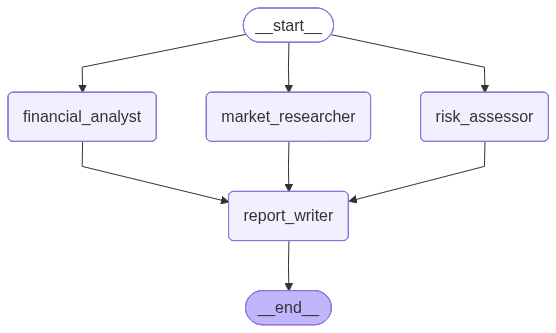

In [7]:
try:
    from IPython.display import Image
    display(Image(lg_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f'Graph visualization skipped (requires graphviz): {e}')

### Step 8 — Run the LangGraph pipeline

In [8]:
print('=' * 65)
print('RUNNING LANGGRAPH PIPELINE  |  OpenAI gpt-4o-mini')
print('=' * 65)

initial_state = {
    'startup':            STARTUP_IDEA,
    'market_research':    '',
    'financial_analysis': '',
    'risk_assessment':    '',
    'investment_memo':    '',
}

lg_start  = time.time()
lg_result = lg_app.invoke(initial_state)
lg_time   = time.time() - lg_start

print(f'\nDone in {lg_time:.1f}s')

RUNNING LANGGRAPH PIPELINE  |  OpenAI gpt-4o-mini
  [LangGraph] Financial Analyst analyzing...
  [LangGraph] Market Researcher analyzing...
  [LangGraph] Risk Assessor analyzing...
  [LangGraph] Report Writer synthesizing memo...

Done in 11.6s


In [9]:
sep = '-' * 65

print(sep)
print('MARKET RESEARCH  (LangGraph / GPT-4o-mini)')
print(sep)
print(lg_result['market_research'])

print()
print(sep)
print('FINANCIAL ANALYSIS  (LangGraph / GPT-4o-mini)')
print(sep)
print(lg_result['financial_analysis'])

print()
print(sep)
print('RISK ASSESSMENT  (LangGraph / GPT-4o-mini)')
print(sep)
print(lg_result['risk_assessment'])

print()
print('=' * 65)
print('INVESTMENT MEMO  (LangGraph / GPT-4o-mini)')
print('=' * 65)
print(lg_result['investment_memo'])

-----------------------------------------------------------------
MARKET RESEARCH  (LangGraph / GPT-4o-mini)
-----------------------------------------------------------------
LegalMind AI operates within the legal tech sector, targeting a Total Addressable Market (TAM) of approximately $4 billion, driven by the estimated 50,000 small and mid-size law firms in the U.S. The legal tech market is projected to grow at a CAGR of 5.5% through 2027, fueled by increasing demand for efficiency and cost reduction in legal services.

The primary customer segments include small law firms with 1-10 attorneys, who often lack the resources for extensive legal research and compliance teams. Personas include managing partners and solo practitioners seeking to streamline operations and enhance service delivery.

The competitive landscape features established players like Clio, LegalZoom, and DocuSign, alongside emerging startups. LegalMind AI's focus on AI-driven document review positions it uniquely, bu

---
## Part 2 — Claude Agent SDK (Anthropic)

The Claude Agent SDK approach uses **plain Python functions** to orchestrate agents. Each specialist is an independent `client.messages.create()` call with a targeted system prompt. The orchestrator function chains them together and synthesizes the results — no graph definition required.

```
run_claude_orchestrator(startup)
    ├── run_claude_specialist(MARKET_PROMPT, startup)    → market_research
    ├── run_claude_specialist(FINANCIAL_PROMPT, startup) → financial_analysis
    ├── run_claude_specialist(RISK_PROMPT, startup)      → risk_assessment
    └── run_claude_specialist(WRITER_PROMPT, synthesis)  → investment_memo
```

### Step 9 — Define Claude Agent SDK specialists and orchestrator

In [10]:
claude = anthropic.Anthropic()

def run_claude_specialist(system_prompt: str, task: str, max_tokens: int = 800) -> str:
    """Run a single Claude specialist agent with a given role and task."""
    response = claude.messages.create(
        model='claude-haiku-4-5-20251001',
        max_tokens=max_tokens,
        system=system_prompt,
        messages=[{'role': 'user', 'content': task}],
    )
    return response.content[0].text


def run_claude_orchestrator(startup: str) -> dict:
    """
    Orchestrates three specialist Claude agents and synthesizes
    their outputs into a final investment memo.

    Unlike LangGraph, the orchestration logic lives entirely in
    plain Python — no graph definition, no state schema required.
    """
    print('  [Claude SDK] Market Researcher analyzing...')
    market_research = run_claude_specialist(MARKET_PROMPT, startup)

    print('  [Claude SDK] Financial Analyst analyzing...')
    financial_analysis = run_claude_specialist(FINANCIAL_PROMPT, startup)

    print('  [Claude SDK] Risk Assessor analyzing...')
    risk_assessment = run_claude_specialist(RISK_PROMPT, startup)

    print('  [Claude SDK] Report Writer synthesizing memo...')
    synthesis = '\n\n'.join([
        'Startup: ' + startup,
        'Market Research:\n'    + market_research,
        'Financial Analysis:\n' + financial_analysis,
        'Risk Assessment:\n'    + risk_assessment,
    ])
    investment_memo = run_claude_specialist(WRITER_PROMPT, synthesis, max_tokens=1200)

    return {
        'startup':            startup,
        'market_research':    market_research,
        'financial_analysis': financial_analysis,
        'risk_assessment':    risk_assessment,
        'investment_memo':    investment_memo,
    }

print('Claude Agent SDK functions defined.')

Claude Agent SDK functions defined.


### Step 10 — Run the Claude Agent SDK pipeline

In [11]:
print('=' * 65)
print('RUNNING CLAUDE AGENT SDK  |  Anthropic claude-haiku-4-5')
print('=' * 65)

claude_start  = time.time()
claude_result = run_claude_orchestrator(STARTUP_IDEA)
claude_time   = time.time() - claude_start

print(f'\nDone in {claude_time:.1f}s')

RUNNING CLAUDE AGENT SDK  |  Anthropic claude-haiku-4-5
  [Claude SDK] Market Researcher analyzing...
  [Claude SDK] Financial Analyst analyzing...
  [Claude SDK] Risk Assessor analyzing...
  [Claude SDK] Report Writer synthesizing memo...

Done in 27.4s


In [12]:
sep = '-' * 65

print(sep)
print('MARKET RESEARCH  (Claude Agent SDK / Haiku)')
print(sep)
print(claude_result['market_research'])

print()
print(sep)
print('FINANCIAL ANALYSIS  (Claude Agent SDK / Haiku)')
print(sep)
print(claude_result['financial_analysis'])

print()
print(sep)
print('RISK ASSESSMENT  (Claude Agent SDK / Haiku)')
print(sep)
print(claude_result['risk_assessment'])

print()
print('=' * 65)
print('INVESTMENT MEMO  (Claude Agent SDK / Haiku)')
print('=' * 65)
print(claude_result['investment_memo'])

-----------------------------------------------------------------
MARKET RESEARCH  (Claude Agent SDK / Haiku)
-----------------------------------------------------------------
# LegalMind AI – Market Analysis

## TAM & Growth
**TAM: ~$1.8B annually** (50,000 US law firms × average 5 attorney seats × $299/month × 12). The legal tech market grows at 12-15% CAGR; document automation specifically at 18-22% driven by labor cost pressures and AI adoption acceleration.

## Target Segments
**Primary:** Solo practitioners and 2-10 attorney boutique firms (~35,000 firms) managing high contract volume (M&A, real estate, compliance-heavy practice areas). **Personas:** Managing partners aged 40-55 seeking operational efficiency; junior associates burdened by review work.

## Competitive Landscape
**Established players:** Westlaw/LexisNexis (enterprise-focused, expensive), Kira Systems (~$100K+ annually, mid-market), Everlaw (e-discovery). **Emerging competitors:** Contract AI startups (AI-Lawyer, L

---
## Part 3 — Side-by-Side Comparison

In [13]:
rows = [
    ('Metric',               'LangGraph',                          'Claude Agent SDK'),
    ('-' * 24,               '-' * 32,                             '-' * 32),
    ('Model',                'OpenAI gpt-4o-mini',                 'Anthropic claude-haiku-4-5'),
    ('Execution time',       f'{lg_time:.1f}s',                    f'{claude_time:.1f}s'),
    ('Lines of agent code',  '~50',                                '~30'),
    ('Orchestration',        'Explicit state graph',               'Imperative Python functions'),
    ('Parallelism',          'Native fan-out / fan-in',            'Sequential (asyncio optional)'),
    ('State management',     'TypedDict with typed keys',          'Plain Python dict'),
    ('Graph visualization',  'Built-in (Mermaid / PNG)',           'None (code is the spec)'),
    ('Conditional routing',  'add_conditional_edges()',            'if/else in Python'),
    ('Learning curve',       'Medium (graph mental model)',        'Low (standard Python)'),
    ('Observability',        'LangSmith tracing built-in',         'Bring your own'),
    ('Best for',             'Complex branching workflows',        'Quick prototyping / flexibility'),
]

col_w = [max(len(r[i]) for r in rows) for i in range(3)]
fmt   = '  '.join(f'{{:<{w}}}' for w in col_w)

print('\nFRAMEWORK COMPARISON')
for row in rows:
    print(fmt.format(*row))


FRAMEWORK COMPARISON
Metric                    LangGraph                         Claude Agent SDK                
------------------------  --------------------------------  --------------------------------
Model                     OpenAI gpt-4o-mini                Anthropic claude-haiku-4-5      
Execution time            11.6s                             27.4s                           
Lines of agent code       ~50                               ~30                             
Orchestration             Explicit state graph              Imperative Python functions     
Parallelism               Native fan-out / fan-in           Sequential (asyncio optional)   
State management          TypedDict with typed keys         Plain Python dict               
Graph visualization       Built-in (Mermaid / PNG)          None (code is the spec)         
Conditional routing       add_conditional_edges()           if/else in Python               
Learning curve            Medium (graph mental m

## Key Takeaways

### Choose LangGraph when:
- Your workflow has **conditional branching** (route to different agents based on output)
- You need **parallel execution** expressed declaratively (fan-out / fan-in)
- You want **built-in observability** via LangSmith
- The pipeline has **cycles** (agents looping back for refinement)
- You need **checkpointing / resumability** for long-running workflows

### Choose Claude Agent SDK when:
- You want **minimal framework overhead** — just Python and the Anthropic SDK
- You're **prototyping quickly** and the flow is straightforward
- Your orchestration logic is **dynamic** and hard to express as a static graph
- You prefer **full control** over the execution loop without abstractions
- You're building a single-provider Anthropic stack with no other LLMs

### The Verdict for this Use Case
Both produce high-quality investment memos. LangGraph adds ~20 lines of graph wiring but gains native parallelism and a visual architecture. The Claude SDK is more concise but sequential by default. For **production multi-agent systems with complex routing**, LangGraph is the stronger choice. For **scripts and rapid prototyping**, the Claude SDK wins on simplicity.